# Palette Extraction – Batch Version (LAB + K-means)
Reads all images from `test_cases/`, converts to LAB color space, applies K-means clustering to extract palette, then converts back to BGR for output. Saves quantized images to `outputs/`.

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pathlib import Path
%matplotlib inline

In [22]:
# ===== CONFIGURATION =====
INPUT_DIR = Path(r"D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Project\test_cases")    # <-- change as needed
OUTPUT_DIR = Path(r"D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Project\palette_logic\ver.2_LAB_colors\outputs")     # <-- change as needed
PALETTE_SIZE = 32
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
# =========================

# Ensure output directory exists
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Check input directory
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"Input folder not found: {INPUT_DIR.resolve()}")

In [23]:
def palette(img, palette_size=32):
    '''
    Accepts BGR image.
    Returns: (labels, centroids) – centroids in BGR.
    Stages:
    1. Convert image to LAB color space.
    2. Apply K-means clustering on LAB pixels.
    3. Convert centroids back to BGR.
    '''
    # Convert to LAB
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    pixels = img_lab.reshape(-1, 3).astype(np.float32)
    
    # K-means
    kmeans = KMeans(n_clusters=palette_size, init="k-means++", random_state=42)
    kmeans.fit(pixels)
    
    # Get labels and centroids in LAB
    labels = kmeans.labels_.reshape(img.shape[:2])
    centroids_lab = kmeans.cluster_centers_
    
    # Convert centroids back to BGR
    centroids_bgr = cv2.cvtColor(centroids_lab.astype(np.uint8).reshape(1, -1, 3), cv2.COLOR_LAB2BGR).reshape(-1, 3)
    
    return labels, centroids_bgr


def visualize(color_map, colors, output_path):
    """Save the quantized image (BGR) to the given path."""
    image = colors[color_map].astype(np.uint8)
    cv2.imwrite(str(output_path), image)

In [24]:
# ===== BATCH PROCESSING =====
processed = 0
for img_path in sorted(INPUT_DIR.iterdir()):
    # Skip non-image files
    if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    if not img_path.is_file():
        continue

    # Build output path
    out_name = f"{img_path.stem}_palette_ver2_lab_{PALETTE_SIZE}colors.png"
    out_path = OUTPUT_DIR / out_name

    # Skip duplicates
    if out_path.exists():
        print(f"⏩ Skipping (already exists): {img_path.name}")
        continue

    # Read image
    img = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img is None:
        print(f"⚠️  Could not read: {img_path.name}")
        continue

    print(f"Processing: {img_path.name} ...")
    color_map, colors = palette(img, palette_size=PALETTE_SIZE)
    visualize(color_map, colors, out_path)

    processed += 1

print(f"\nDone. {processed} image(s) processed. Output folder: {OUTPUT_DIR.resolve()}")

⏩ Skipping (already exists): albert.jpg
⏩ Skipping (already exists): gradient_descending.png
⏩ Skipping (already exists): hatsune_miku.jpg
⏩ Skipping (already exists): mona_lisa.jpg
⏩ Skipping (already exists): test_case.png
⏩ Skipping (already exists): van_gogh_starsky.jpg
⏩ Skipping (already exists): why_are_you_sitting.jpg

Done. 0 image(s) processed. Output folder: D:\pythonProject\Private\CUHKSZ Schoolwork\Y1T2S\ECE4512\Project\palette_logic\ver.2_LAB_colors\outputs


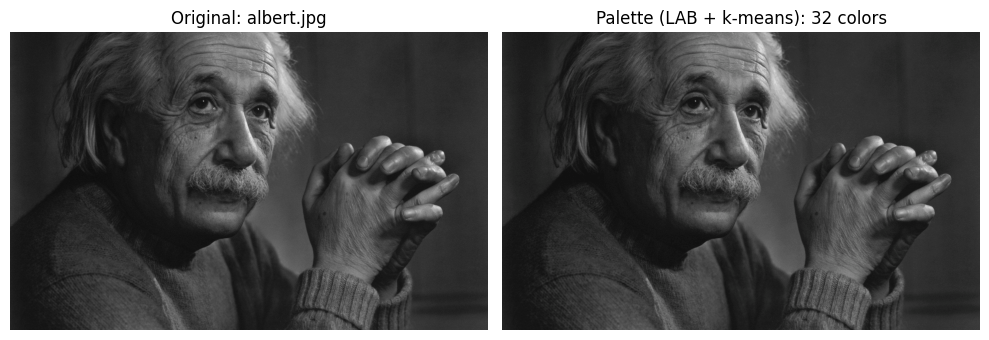

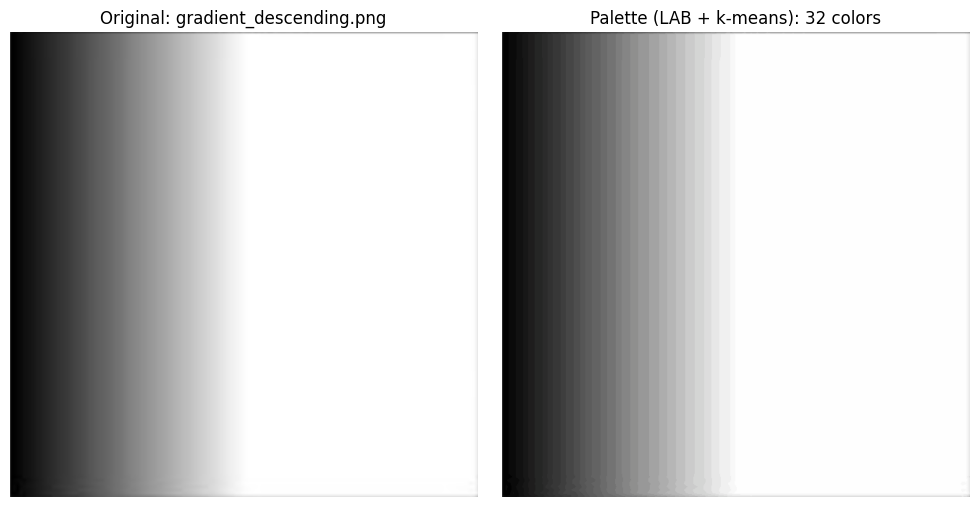

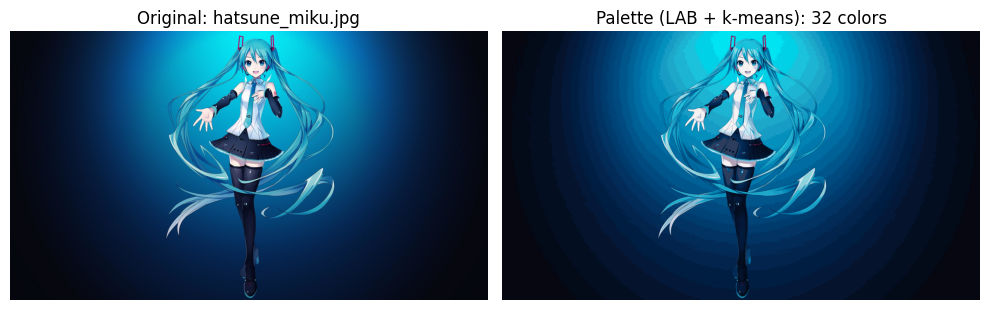

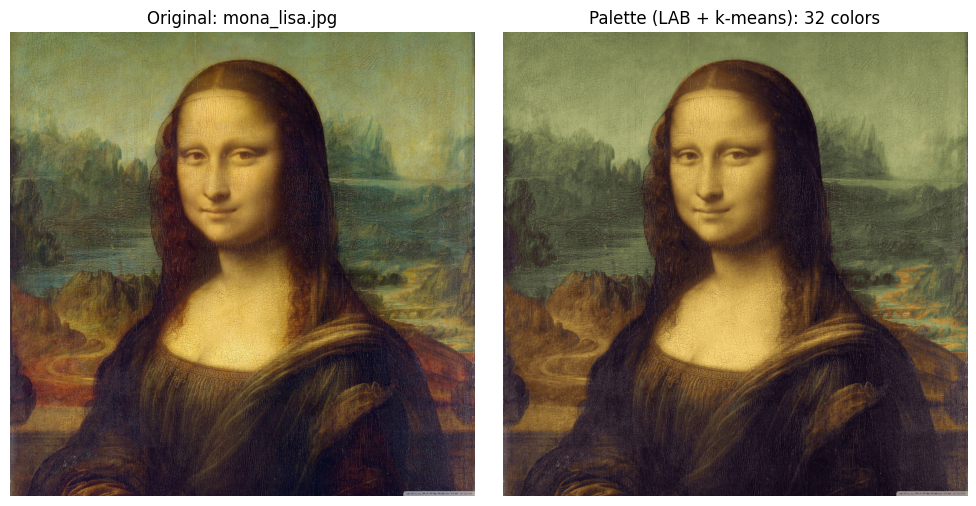

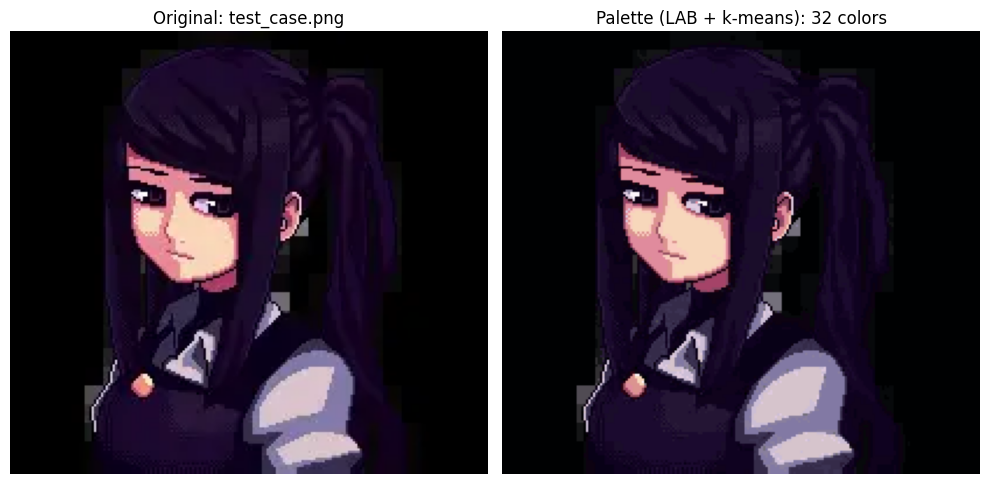

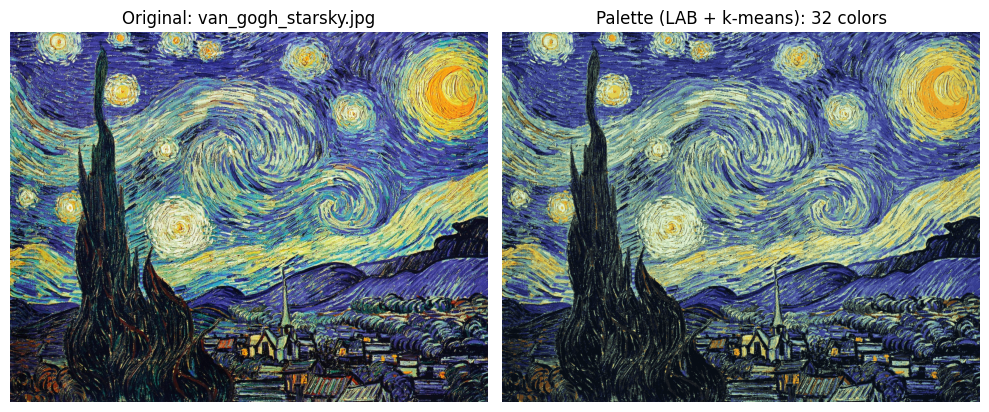

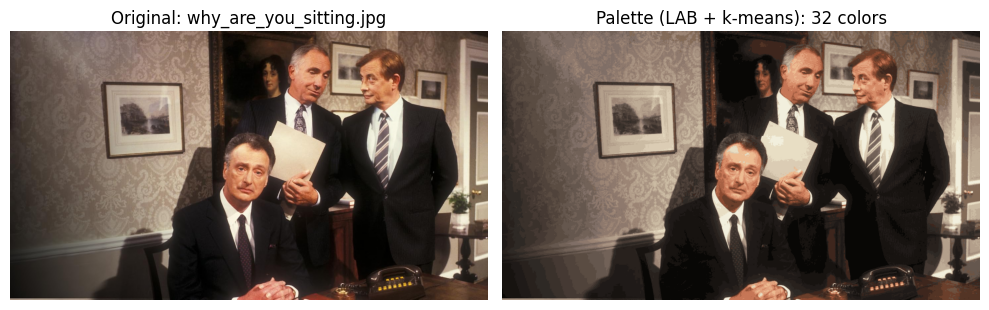

In [25]:
# Toggle on/off
SHOW_COMPARISONS = True

if SHOW_COMPARISONS:
    for img_path in sorted(INPUT_DIR.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        out_name = f"{img_path.stem}_palette_ver2_lab_{PALETTE_SIZE}colors.png"
        out_path = OUTPUT_DIR / out_name
        if not out_path.exists():
            continue

        orig_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        quant_bgr = cv2.imread(str(out_path), cv2.IMREAD_COLOR)
        if orig_bgr is None or quant_bgr is None:
            continue

        # BGR -> RGB for matplotlib
        orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
        quant_rgb = cv2.cvtColor(quant_bgr, cv2.COLOR_BGR2RGB)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
        ax1.imshow(orig_rgb)
        ax1.set_title(f"Original: {img_path.name}")
        ax1.axis("off")
        ax2.imshow(quant_rgb)
        ax2.set_title(f"Palette (LAB + k-means): {PALETTE_SIZE} colors")
        ax2.axis("off")
        plt.tight_layout()
        plt.show()